In [1]:
import spd
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.spd_simulator import SPD_Simulator
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15
from functools import partial

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['39.82GB', '42.41GB']


In [4]:
def spd_sim(p,N,P0=1,**kwargs):
    return SPD_Simulator(p=p,
                  N=(N// 4, N),
                  xlim=(0.0, 0.25),
                  ylim=(0.0, 1.0),
                  BC=(("periodic", "periodic"),  # x
                      ("reflective", "reflective"),  # y
                     ),
                  init_fct=ic.RTI(P0=1,gamma=5/3),
                  cfl_coeff=0.4,use_cupy=True,
                  time_integrator="rk3",
                  fallback="MUSCL",
                  scheme="SDFB",
                  potential=True,
                  NAD="",
                  PAD=True,
                  SED=True,
                  blending=False,
                  riemann_solver_fv="hllc",  # MUSCL fallback flux
                  **kwargs)
    

t=nan, steps taken 931, time taken 66.331, bzcps = 0.0


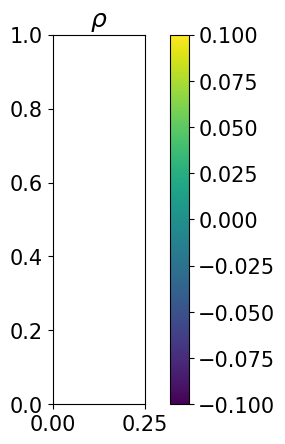

In [5]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-1,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 3587, time taken 257.288, bzcps = 0.0


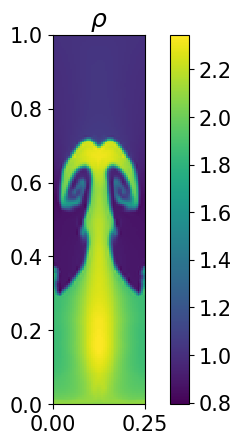

In [6]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 3588, time taken 255.803, bzcps = 0.0


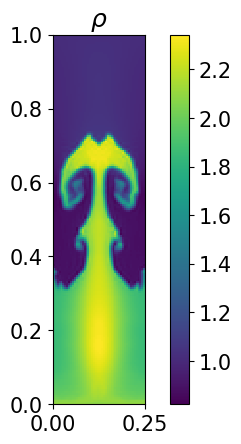

In [7]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=nan, steps taken 1055, time taken 62.595, bzcps = 0.0


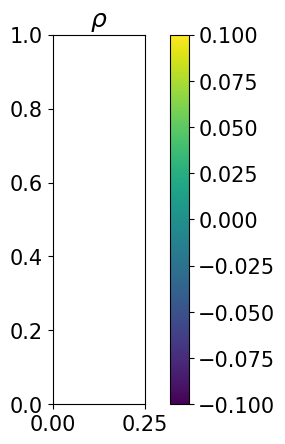

In [8]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-1,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 3590, time taken 256.471, bzcps = 0.0


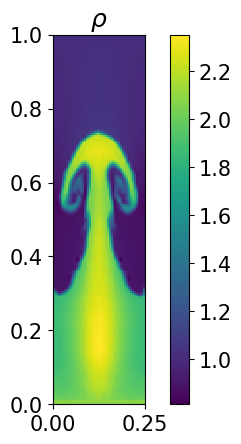

In [9]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 3613, time taken 216.176, bzcps = 0.0


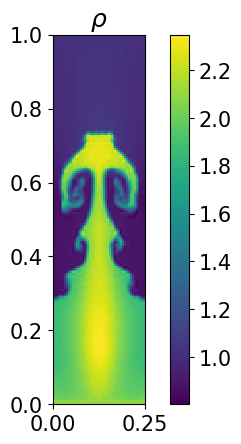

In [10]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 3699, time taken 262.287, bzcps = 0.0


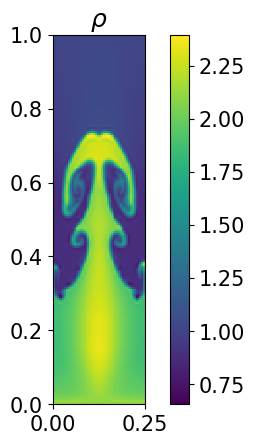

In [11]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-2,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")